# PHT3D Example 4 — cation exchange

MF6PQC reproduction of the official PHT3D Example 4 breakthrough curves. The official numerical results are stored in `input_data/official_reference.npz`.

In [2]:
import os
import sys
from pathlib import Path

sys.dont_write_bytecode = True
_name = "PHT3D_E04"
_candidates = [
    p for base in (Path.cwd(), *Path.cwd().parents) for p in (base, base / "examples" / _name)
]
CASE_DIR = next(
    (p.resolve() for p in _candidates if p.name == _name and (p / "modflow_model.py").is_file()),
    None,
)
if CASE_DIR is None:
    raise FileNotFoundError(f"Cannot locate examples/{_name} from {Path.cwd()}")
os.chdir(CASE_DIR)
sys.path.insert(0, str(CASE_DIR))
__file__ = str(CASE_DIR / "plot.ipynb")
from modflow_model import runtime_path

OUTPUT_DIR = CASE_DIR / "output"
SIMULATION_DIR = CASE_DIR / "simulation"

# Saved numerical outputs are distributed losslessly; solver logs are omitted.
import zipfile

for _kind in ("output", "simulation"):
    _base = CASE_DIR / _kind
    for _archive in sorted(_base.glob("saved_results*.zip")):
        with zipfile.ZipFile(_archive) as _zip:
            for _member in _zip.infolist():
                _target = (_base / _member.filename).resolve()
                if not _target.is_relative_to(_base.resolve()):
                    raise ValueError("Archive member escapes the case directory")
                if not _target.exists():
                    _zip.extract(_member, _base)

In [3]:
"""Loading, comparison, and plotting helpers for PHT3D Example 4."""


import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

SPECIES = ("Ca", "Cl", "Na", "K")


COLORS = {"Ca": "red", "Cl": "blue", "Na": "magenta", "K": "green"}


YLABELS = {
    "Ca": r"Ca (mmol L$^{-1}$)",
    "Cl": r"Cl (mmol L$^{-1}$)",
    "Na": r"Na (mmol L$^{-1}$)",
    "K": r"K (mmol L$^{-1}$)",
}


def load_comparison(case_dir: str | Path):
    """Load MF6PQC selected output and the extracted official outlet curves."""
    case_dir = Path(case_dir)
    results = np.load(runtime_path(__file__, "output") / "results.npy")
    headings = (
        (runtime_path(__file__, "output") / "results_headings.txt")
        .read_text(encoding="utf-8")
        .splitlines()
    )
    official = np.load(case_dir / "input_data" / "official_reference.npz")

    if results.shape[0] != official["pore_volumes"].size:
        raise ValueError(
            "MF6PQC and official result counts differ: "
            f"{results.shape[0]} != {official['pore_volumes'].size}"
        )

    mf6pqc = {species: results[:, headings.index(species), -1] * 1000.0 for species in SPECIES}
    pht3d = {species: official[species] * 1000.0 for species in SPECIES}
    return official["pore_volumes"], mf6pqc, pht3d


def comparison_metrics(mf6pqc: dict, pht3d: dict) -> dict:
    """Return RMSE, normalized RMSE, maximum error, and correlation."""
    metrics = {}
    for species in SPECIES:
        calculated = np.asarray(mf6pqc[species])
        reference = np.asarray(pht3d[species])
        residual = calculated - reference
        scale = np.ptp(reference)
        metrics[species] = {
            "RMSE (mmol/L)": float(np.sqrt(np.mean(residual**2))),
            "NRMSE": float(np.sqrt(np.mean(residual**2)) / scale),
            "Max abs. error (mmol/L)": float(np.max(np.abs(residual))),
            "Correlation": float(np.corrcoef(calculated, reference)[0, 1]),
        }
    return metrics


def plot_official_style(pore_volumes, mf6pqc, pht3d):
    """Recreate the official E04 breakthrough figure."""
    fig, ax = plt.subplots(figsize=(12.4, 6.2))

    # Preserve the official legend ordering: four lines, then four point sets.
    for species in SPECIES:
        ax.plot(
            pore_volumes,
            mf6pqc[species],
            color=COLORS[species],
            linewidth=1.5,
            label=f"{species} (MF6PQC)",
        )
    for species in SPECIES:
        ax.plot(
            pore_volumes,
            pht3d[species],
            linestyle="none",
            marker="o",
            markersize=4.2,
            markerfacecolor=COLORS[species],
            markeredgecolor="black",
            markeredgewidth=0.35,
            label=f"{species} (PHT3D)",
        )

    ax.set_xlim(0.0, 3.0)
    ax.set_ylim(0.0, 1.2)
    ax.set_xlabel("PV", fontsize=14)
    ax.set_ylabel(r"(mmol L$^{-1}$)", fontsize=14)
    ax.tick_params(labelsize=12, direction="in", top=True, right=True)
    ax.legend(
        loc="upper right",
        ncol=1,
        fontsize=10.5,
        frameon=True,
        fancybox=False,
        edgecolor="black",
        framealpha=1.0,
    )
    fig.tight_layout()
    return fig, ax


def plot_species_panels(pore_volumes, mf6pqc, pht3d):
    """Plot one direct comparison panel per transported cation/anion."""
    fig, axes = plt.subplots(2, 2, figsize=(10.5, 7.0), sharex=True)
    for ax, species in zip(axes.flat, SPECIES, strict=False):
        ax.plot(
            pore_volumes,
            mf6pqc[species],
            color=COLORS[species],
            linewidth=1.8,
            label="MF6PQC",
        )
        ax.scatter(
            pore_volumes,
            pht3d[species],
            s=13,
            color=COLORS[species],
            edgecolor="black",
            linewidth=0.3,
            label="PHT3D",
            zorder=3,
        )
        ax.set_ylabel(YLABELS[species])
        ax.set_xlim(0.0, 3.0)
        ax.grid(alpha=0.2)
        ax.legend(frameon=False)
    axes[1, 0].set_xlabel("Pore volumes")
    axes[1, 1].set_xlabel("Pore volumes")
    fig.tight_layout()
    return fig, axes


def plot_residuals(pore_volumes, mf6pqc, pht3d):
    """Plot MF6PQC minus official PHT3D outlet concentrations."""
    fig, ax = plt.subplots(figsize=(10.5, 4.5))
    for species in SPECIES:
        ax.plot(
            pore_volumes,
            np.asarray(mf6pqc[species]) - np.asarray(pht3d[species]),
            color=COLORS[species],
            label=species,
        )
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_xlim(0.0, 3.0)
    ax.set_xlabel("Pore volumes")
    ax.set_ylabel(r"MF6PQC - PHT3D (mmol L$^{-1}$)")
    ax.grid(alpha=0.2)
    ax.legend(frameon=False, ncol=4)
    fig.tight_layout()
    return fig, ax

In [4]:
import sys
from pathlib import Path

import pandas as pd

CASE_DIR = Path.cwd()
if CASE_DIR.name != "PHT3D_E04":
    CASE_DIR = CASE_DIR / "examples" / "PHT3D_E04"
sys.path.insert(0, str(CASE_DIR))


plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 200})
pore_volumes, mf6pqc, pht3d = load_comparison(CASE_DIR)

## Official-style breakthrough comparison

Lines are MF6PQC and points are the official PHT3D UCN values at the outlet cell. Colors, axes, limits, species, and point/line convention follow the original Example 4 figure.

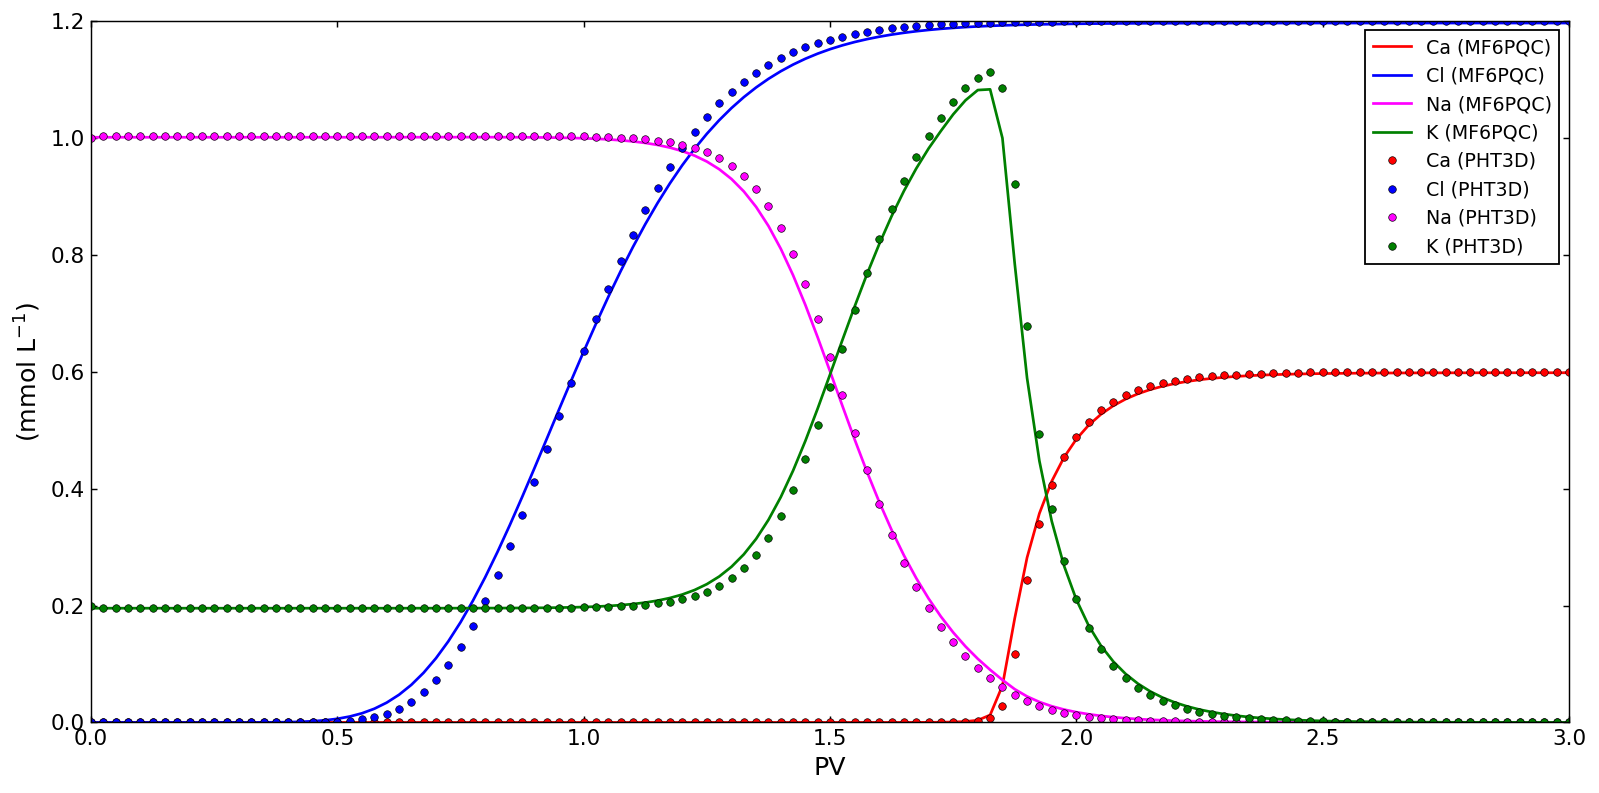

In [5]:
fig, ax = plot_official_style(pore_volumes, mf6pqc, pht3d)
plt.show()

## Species-by-species comparison

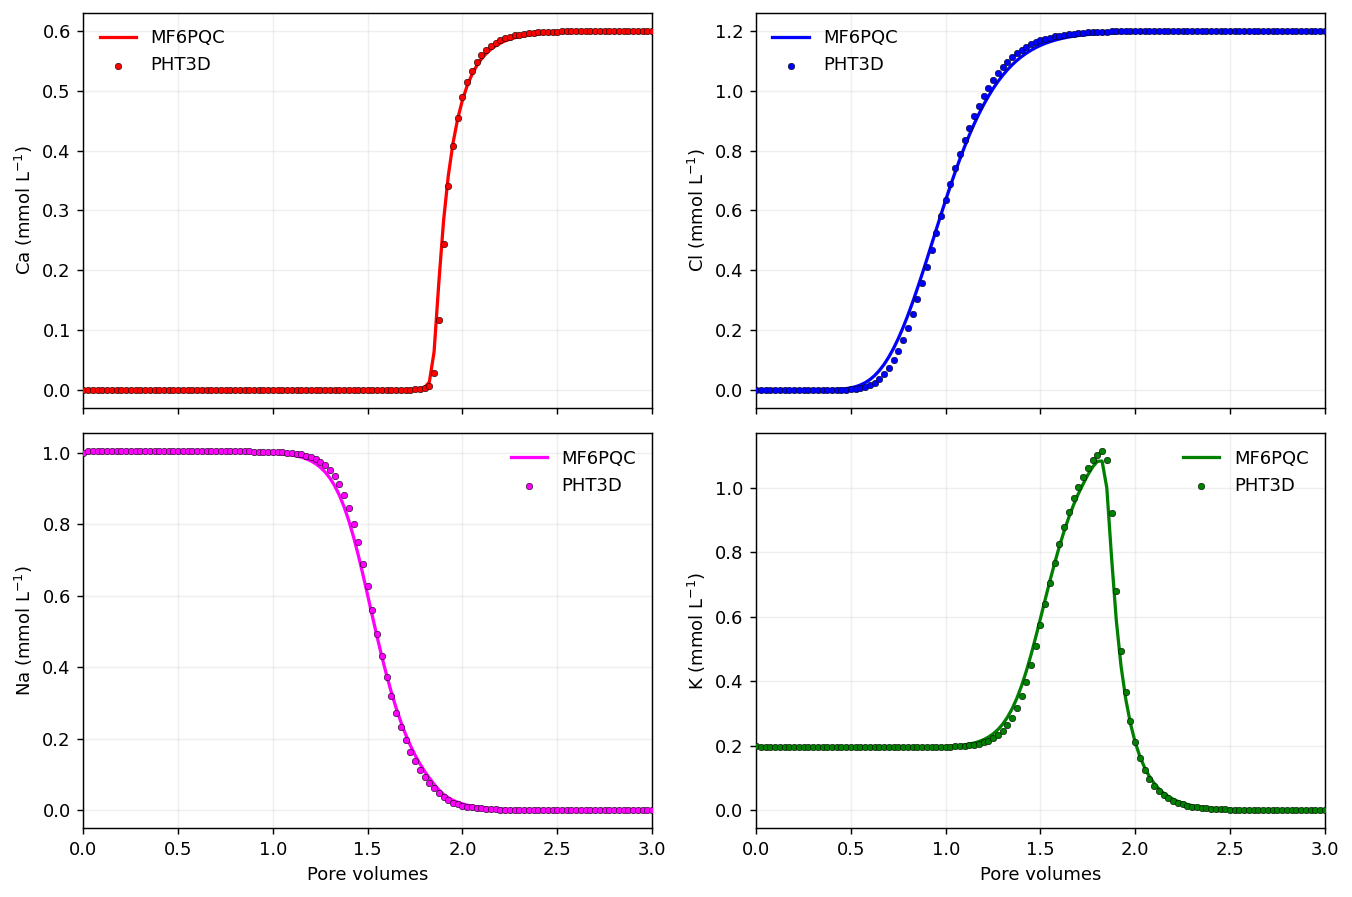

In [6]:
fig, axes = plot_species_panels(pore_volumes, mf6pqc, pht3d)
plt.show()

## Residuals and quantitative diagnostics

NRMSE is normalized by the official concentration range.

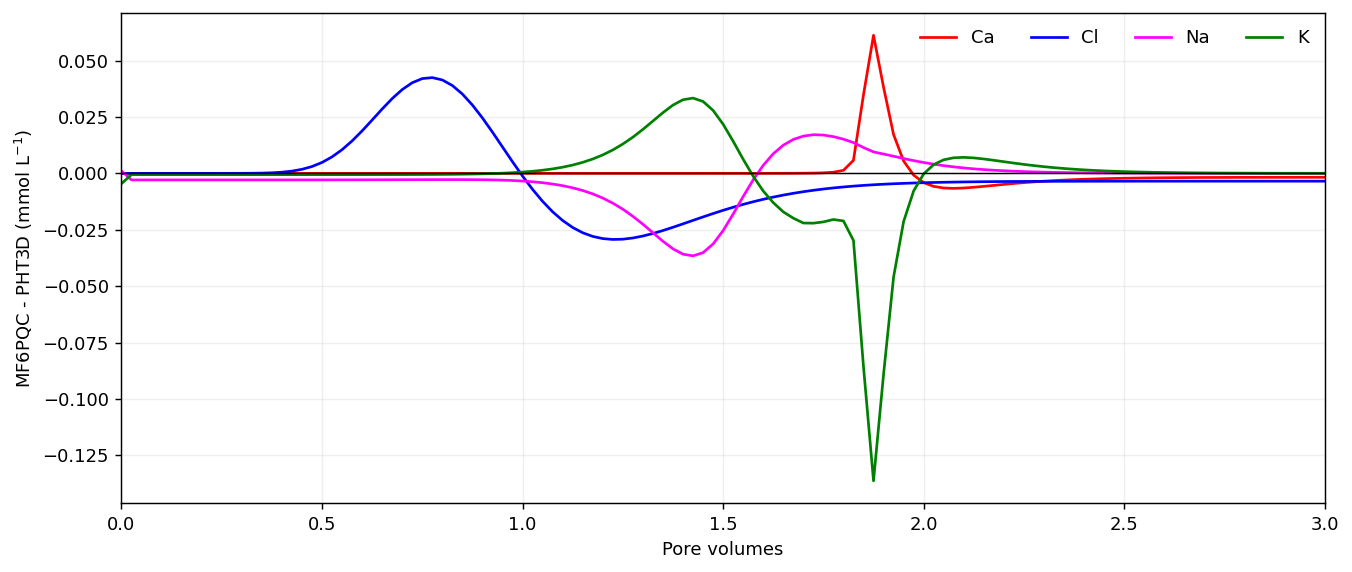

,RMSE (mmol/L),NRMSE,Max abs. error (mmol/L),Correlation
Ca,0.007750,0.012916,0.061191,0.999623
Cl,0.015518,0.012932,0.042427,0.999682
Na,0.010433,0.010391,0.036576,0.999815
K,0.020111,0.018072,0.136292,0.998073


In [7]:
fig, ax = plot_residuals(pore_volumes, mf6pqc, pht3d)
plt.show()

metrics = pd.DataFrame(comparison_metrics(mf6pqc, pht3d)).T
metrics

## 数值核对

只检查已有结果，不启动模型。

In [8]:
"""Quantitatively validate MF6PQC E04 against the official PHT3D output."""


import sys
from pathlib import Path

CASE_DIR = CASE_DIR


MAX_NRMSE = 0.03


MIN_CORRELATION = 0.995


def validate_saved_results() -> None:
    _, mf6pqc, pht3d = load_comparison(CASE_DIR)
    metrics = comparison_metrics(mf6pqc, pht3d)

    print("species  NRMSE       correlation  RMSE (mmol/L)")
    for species, values in metrics.items():
        print(
            f"{species:>7}  {values['NRMSE']:.6f}   "
            f"{values['Correlation']:.6f}     "
            f"{values['RMSE (mmol/L)']:.6f}"
        )
        if values["NRMSE"] > MAX_NRMSE:
            raise AssertionError(f"{species} NRMSE exceeds {MAX_NRMSE}")
        if values["Correlation"] < MIN_CORRELATION:
            raise AssertionError(f"{species} correlation is below {MIN_CORRELATION}")

    print("Validation passed.")


validate_saved_results()

species  NRMSE       correlation  RMSE (mmol/L)
     Ca  0.012916   0.999623     0.007750
     Cl  0.012932   0.999682     0.015518
     Na  0.010391   0.999815     0.010433
      K  0.018072   0.998073     0.020111
Validation passed.
